# Hyperscaler Capital Expenditure and GPU/Memory Demand: An Exploratory Analysis

As hyperscaler AI infrastructure capex ramps, how closely and with what lag does that show up in memory and GPU supplier revenue, margins, and HBM demand?

In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'matplotlib', 'seaborn'], returncode=0)

#### 1. Data Loading: Hyperscaler Capital Expenditure

This section loads quarterly financial data for five hyperscalers — Microsoft, Amazon, Meta, Google, and Oracle. Covering operating cash flow (`ocf_bn`), capital expenditure (`capex_bn`), and share buybacks (`buybacks_bn`) from Q1 2024 through Q1 2026, sourced from quarterly earnings
releases and 10-Q filings. Since the `quarter` column is stored as text (e.g. "Q1 2024"), it's converted into a proper sortable period (`quarter_dt`) to ensure correct chronological ordering in all charts and calculations that follow. The data loaded from this serves are the foundation for the analysis in the other sections below.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

hyperscaler_raw = pd.read_csv("data/Hyperscaler Financials Data - Cleaned Data.csv")
hyperscaler_raw = hyperscaler_raw.dropna(how="all")

#quarter as a sortable period for correct chronological ordering in plots
hyperscaler_raw["quarter_dt"] = pd.PeriodIndex(
    hyperscaler_raw["quarter"].str.replace(r"Q(\d) (\d+)", r"\2-Q\1", regex=True),
    freq="Q"
)
hyperscaler_raw = hyperscaler_raw.sort_values(["company", "quarter_dt"])
hyperscaler_raw.head(5)

,company,quarter,ocf_bn,capex_bn,buybacks_bn,quarter_dt
1,Amazon,Q1 2024,18.99,14.93,0.0,2024Q1
6,Amazon,Q2 2024,25.28,17.62,0.0,2024Q2
11,Amazon,Q3 2024,25.97,22.62,0.0,2024Q3
16,Amazon,Q4 2024,45.64,27.83,0.0,2024Q4
21,Amazon,Q1 2025,17.02,25.02,0.0,2025Q1


#### 2. Combined Hyperscaler Capex Trend

Aggregating capex across all five hyperscalers shows combined quarterly spend rising from
 USD 47.09 billion (Q1 2024) to USD 146.24 billion (Q1 2026), roughly a 3.1x increase over 9 quarters (2.25 years). However, there was a brief slowdown between Q4 2024 (USD78.20 billion) and Q1 2025 (USD80.99 billion), before capex accelerated sharply from Q3 2025 onward.

The stacked area chart below shows each company's individual contribution to that total:

- **Amazon** has been the largest single contributor throughout the period, growing from
  USD 14.93 billion to USD 44.20 billion (~3.0x). Growth was fairly steady, aside from a slight pullback between Q4 2024 (USD 27.83 billion) and Q1 2025 (USD 25.02 billion).

- **Google** shows the most consistent acceleration of the five, growing from USD 12.01 billion to
  USD 35.67 billion (~3.0x), with growth actually speeding up in the most recent two quarters
  (Q3 2025 -> Q1 2026: USD 23.95 billion -> USD 27.85 billion -> USD 35.67 billion).

- **Microsoft** grew from USD 10.95 billion to USD 30.88 billion (~2.8x), climbing steadily until a sharp jump between Q3 2025 and Q4 2025 (USD 19.39 billion -> USD 29.88 billion), after which growth flattened into Q1 2026.

- **Meta** grew from USD 6.40 billion to USD 19.00 billion (~3.0x), but with the least smooth trajectory of the five. Capex nearly doubled between Q3 2024 and Q4 2024 (USD 8.26 billion -> USD 14.43 billion), pulled back the following quarter, and is the only company to show a quarter-over-quarter *decline* in the most recent period (Q4 2025 -> Q1 2026: USD 21.38 billion -> USD 19.00 billion).

- **Oracle**, while the smallest absolute contributor, grew the fastest in percentage terms.
  From USD 2.80 billion to USD 16.49 billion, roughly a 5.9x increase. Additionally, its capex-to-operating-cash-flow ratio (shown later in this notebook) was consistently the highest and most volatile of the five, at times exceeding its own operating cash flow several times over.

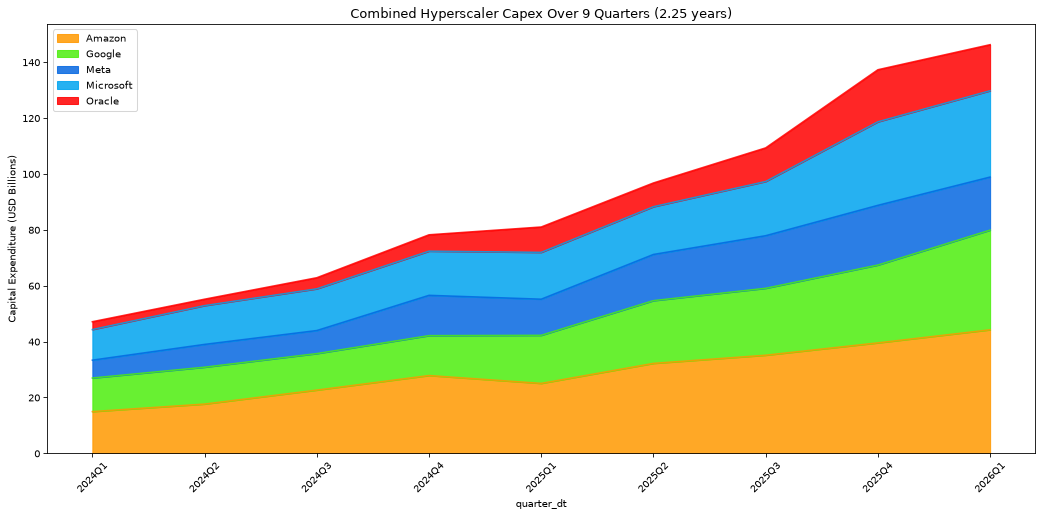

Total Capex by Quarter (USD Billions):

   quarter quarter_dt  capex_usd (billion)
0  Q1 2024     2024Q1                47.09
3  Q2 2024     2024Q2                55.15
5  Q3 2024     2024Q3                62.83
7  Q4 2024     2024Q4                78.20
1  Q1 2025     2025Q1                80.99
4  Q2 2025     2025Q2                96.75
6  Q3 2025     2025Q3               109.30
8  Q4 2025     2025Q4               137.27
2  Q1 2026     2026Q1               146.24

Capex by Company and Quarter (USD Billions):

company     Microsoft  Amazon   Meta  Google  Oracle
quarter_dt                                          
2024Q1          10.95   14.93   6.40   12.01    2.80
2024Q2          13.87   17.62   8.17   13.19    2.30
2024Q3          14.92   22.62   8.26   13.06    3.97
2024Q4          15.80   27.83  14.43   14.28    5.86
2025Q1          16.75   25.02  12.94   17.20    9.08
2025Q2          17.08   32.18  16.54   22.45    8.50
2025Q3          19.39   35.10  18.83   23.95   12.03
2025Q4

In [14]:
plt.rcParams["figure.dpi"] = 75

hyperscaler_capex_total = (
    hyperscaler_raw.groupby(["quarter", "quarter_dt"])["capex_bn"].sum()
    .reset_index().sort_values("quarter_dt")
    .rename(columns={"capex_bn": "capex_usd (billion)"})
)

colors = {
    "Microsoft": "#00A4EF",
    "Amazon": "#FF9900",
    "Meta": "#0668E1",
    "Google": "#4DEE0E",
    "Oracle": "#FF0000"
}

pivot = hyperscaler_raw.pivot(index="quarter_dt", columns="company", values="capex_bn").sort_index()
pivot.index = pivot.index.astype(str)
fig, ax = plt.subplots(figsize=(14, 7))
pivot.plot.area(ax=ax, color=[colors.get(c, "gray") for c in pivot.columns], alpha=0.85)
ax.set_ylabel("Capital Expenditure (USD Billions)")
ax.set_title("Combined Hyperscaler Capex Over 9 Quarters (2.25 years)")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Total Capex by Quarter (USD Billions):\n")
print(hyperscaler_capex_total.head(10))
print("\nCapex by Company and Quarter (USD Billions):\n")
print(pivot[["Microsoft", "Amazon", "Meta", "Google", "Oracle"]])

#### 3. Hyperscaler Capital Expenditure (Capex) Compounded Annual Growth Rate (CAGR) by Company

To compare growth rates on a consistent, annualized basis, CAGR was calculated for each
company's capex from Q1 2024 to Q1 2026 (8 quarters, 2 years).

- **Oracle stands out sharply**, with an annualized capex growth rate of 142.7%, which is more than
  double the CAGR of any other company tracked. This aligns with its consistently elevated
  capex-as-percentage-of-operating-cash-flow ratio shown earlier, reinforcing that Oracle is
  the most aggressive of the five in scaling AI infrastructure spend relative to its own
  financial base. However, Oracle is spending cash that it *does not* have. In other words, Oracle's business is not generating enough cash to fund their AI infrastructure expenditure which will be further elaborated in Section 4 below. It's also important to remember that while Oracle's headline growth rate looks the most dramatic, it's compounding from the smallest starting base (2.80B in Q1 2024) of any company tracked. A high CAGR from a small base is a different signal than the same CAGR from a large one and worth keeping in mind when comparing the five companies directly.

- **Amazon, Google, and Meta spending is relatively similar**, at 72.1%, 72.3%, and 72.3% CAGR
  respectively despite very different capex trajectories in absolute dollar terms (and, in
  Meta's case, a notably less smooth quarter-to-quarter path), all three have compounded at
  almost exactly the same annualized rate over the full 2-year window.

- **Microsoft has the lowest CAGR of the five at 67.9%**, though still a substantial growth
  rate in absolute terms which reflects its comparatively steadier, more gradual capex
  increases relative to Oracle's sharper ramp. Microsoft as a company is also typically more diciplined in their spending compared to their peers.

- **Combined hyperscaler capex grew at a 76.2% CAGR** across the same period which is closely in line with the Amazon/Google/Meta cluster, since those three companies represent the largest share of the total, while Oracle's outsized growth rate (from a much smaller base) has a proportionally smaller effect on the combined figure.

Amazon: 72.1%
Google: 72.3%
Meta: 72.3%
Microsoft: 67.9%
Oracle: 142.7%

Combined Hyperscaler Capex CAGR: 76.2%


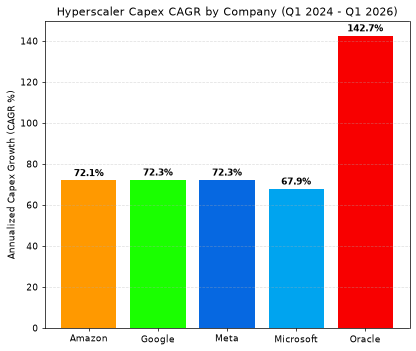

In [15]:
plt.rcParams["figure.dpi"] = 65

colors = {
    "Microsoft": "#00A4EF",
    "Amazon": "#FF9900",
    "Meta": "#0668E1",
    "Google": "#1AFF00",
    "Oracle": "#F80000"
}

#CAGR per company
cagr_by_company = {}
for company in hyperscaler_raw["company"].unique():
    company_data = hyperscaler_raw[hyperscaler_raw["company"] == company].sort_values("quarter_dt")
    capex_values = company_data["capex_bn"].tolist()
    start = capex_values[0]
    end = capex_values[-1]
    num_quarters = len(capex_values) - 1
    cagr = (end / start) ** (4 / num_quarters) - 1
    cagr_by_company[company] = cagr
for company, cagr in cagr_by_company.items():
    print(f"{company}: {cagr:.1%}")

#CAGR for combined total capex
total_by_quarter = hyperscaler_raw.groupby("quarter_dt")["capex_bn"].sum().sort_index()
total_values = total_by_quarter.tolist()
start = total_values[0]
end = total_values[-1]
num_quarters = len(total_values) - 1
total_cagr = (end / start) ** (4 / num_quarters) - 1
print(f"\nCombined Hyperscaler Capex CAGR: {total_cagr:.1%}")

#Bar chart of CAGR by company
companies = list(cagr_by_company.keys())
cagr_values = [cagr_by_company[c] * 100 for c in companies]  # convert to percentage
fig, ax = plt.subplots(figsize=(6.5, 5.5))
bars = ax.bar(companies, cagr_values, color=[colors.get(c, "gray") for c in companies])
for bar, value in zip(bars, cagr_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Annualized Capex Growth (CAGR %)")
ax.set_title("Hyperscaler Capex CAGR by Company (Q1 2024 - Q1 2026)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### 4. Capex Intensity: Capex as a Percentage of Operating Cash Flow

This metric shows how much of each company's own operating cash flow (OCF) is being reinvested
into capital expenditure — **values above 100% mean a company spent more on capex in that quarter
than it generated from its own operations, implying the gap was funded by debt, existing cash
reserves, or equity.**

- **Oracle is the clear outlier**, and by an extreme margin. Its capex-to-OCF ratio exceeded 100%
  in 6 of the 9 quarters tracked, peaking at an extreme 581.2% in Q3 2025, meaning Oracle spent
  nearly 6 times more on capex that quarter than it generated in operating cash flow. **In simpler terms, for every 1 dollar it makes, its spending 6 dollars on capex that quarter**. This directly supports the point raised in Section 3 whereby Oracle's headline-leading capex CAGR is not being funded from its own business operations, but relies heavily on external financing.

- **Amazon is the second most capex-intensive company**, regularly running in the 70-170% range
  and exceeding 100% in 4 of 9 quarters (notably 147.0% in Q1 2025 and 169.8% in Q1 2026). A
  meaningfully more aggressive spending than Google, Meta, or Microsoft, though far less
  extreme than Oracle's.

- **Google, Meta, and Microsoft all stayed within a comparatively narrow, more sustainable
  30-85% range throughout the period**, generally funding their AI infrastructure buildout
  from their own operating cash flow without needing to significantly outspend it. Microsoft's
  highest reading was 83.6% (Q4 2025), Meta peaked at 64.7% (Q2 2025) while Google peaked at 80.9%
  (Q2 2025). All still under 100% which shows their spending is not fueled by debt during this period of time.

- **This creates a clear two-tier pattern among the five hyperscalers**: Oracle (extreme,
  externally-financed growth) and Amazon (moderately aggressive, occasionally over 100%) on one
  side, versus Google, Meta, and Microsoft (self-funded, more conservative) on the other side despite all five showing strong capex CAGR growth in Section 3. 


company      Amazon     Google       Meta  Microsoft      Oracle
quarter                                                         
Q1 2024   78.620326  41.629116  33.246753  34.304511   46.052632
Q2 2024   69.699367  49.512012  42.178627  37.284946   30.955585
Q3 2024   87.100501  42.540717  33.414239  43.651258  305.384615
Q4 2024   60.977213  36.512401  51.554126  70.883804   98.819562
Q1 2025  147.003525  47.579530  53.849355  45.221382  147.402597
Q2 2025   98.954490  80.900901  64.710485  40.046893  104.422604
Q3 2025   98.789755  49.473249  62.766667  43.031514  581.159420
Q4 2025   72.567022  53.148855  59.044463  83.557047  260.699301
Q1 2026  169.804072  77.899105  58.951288  66.152528  112.790698


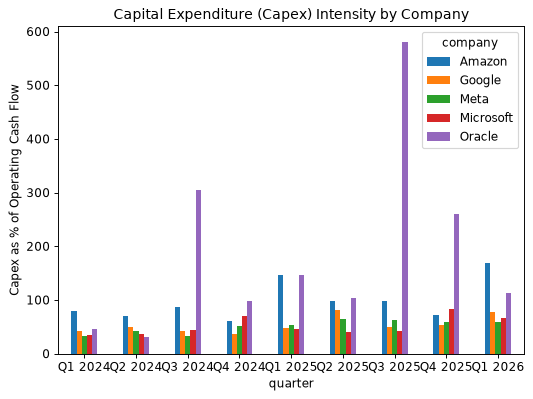

In [16]:
plt.rcParams["figure.dpi"] = 85

hyperscaler_raw["capex_pct_ocf"] = hyperscaler_raw["capex_bn"] / hyperscaler_raw["ocf_bn"] * 100
hyperscaler_raw["buyback_pct_ocf"] = hyperscaler_raw["buybacks_bn"] / hyperscaler_raw["ocf_bn"] * 100
pivot = hyperscaler_raw.pivot(index="quarter", columns="company", values="capex_pct_ocf")

#reorder chronologically to ensure correct order in the bar chart
quarter_order = hyperscaler_raw.sort_values("quarter_dt")["quarter"].unique()
pivot = pivot.reindex(quarter_order)
print(pivot)

#plotting the bar charts
fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Capex as % of Operating Cash Flow")
ax.set_title("Capital Expenditure (Capex) Intensity by Company")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 5. Nvidia's Data Center Revenue: The "Pick and Shovel" of the AI Boom

Hyperscaler capex doesn't just disappear into abstract "infrastructure". A substantial share of
it flows directly into purchasing AI accelerator GPUs, and Nvidia is the dominant supplier of that
hardware. As the hyperscalers race to build out AI compute capacity, Nvidia has positioned itself
as the primary beneficiary of that spending as the classic "pick and shovel seller" of the AI gold
rush, profiting from the buildout regardless of which hyperscaler or AI model ultimately wins.

Looking at Nvidia's revenue history from 2014 through 2026 makes this shift unmistakable. For most
of Nvidia's history, Gaming, Devices, and Automotive was the larger or comparable segment to Data
Centers and AI. That balance flipped decisively starting around late 2023, coinciding with the
sharp acceleration in hyperscaler capital expenditure explored in Sections 2-4 of this notebook.
Since that inflection point, Data Center revenue has grown at an annualized rate of 82.0% and now
makes up the overwhelming majority of Nvidia's total revenue, a complete reversal from its
historically secondary role in the company's business.

This pattern supports the broader thesis of this analysis, as hyperscalers pour increasing capital
into AI infrastructure, Nvidia captures a large and growing share of that spend, making its Data
Center revenue a useful proxy for tracking how hyperscaler capex actually converts into real
demand for AI compute hardware. The critical link between capital spending decisions and the
downstream memory demand explored in the sections that follow.

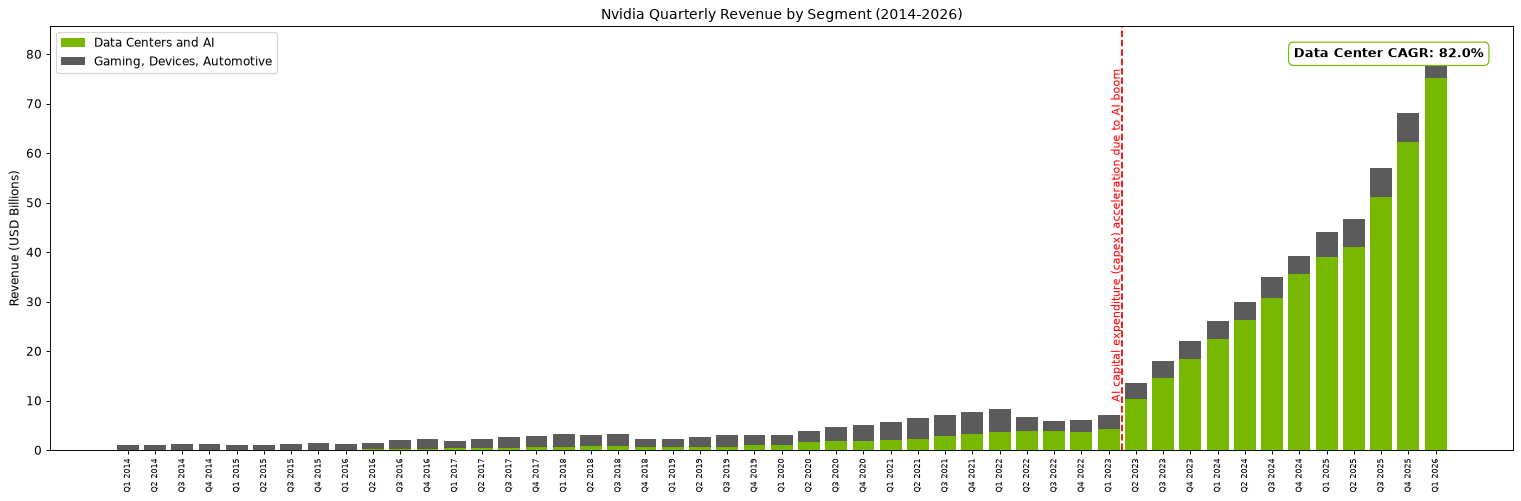

In [17]:
#Load the data
df = pd.read_csv("data/nvidia_quarterly_revenue_segment_cleaned.csv")

#Pull out just the two segments we need
data_center = df[df["Revenue"] == "Data centers and AI"].reset_index(drop=True)
gaming = df[df["Revenue"] == "Gaming, devices, automotive"].reset_index(drop=True)
quarters = data_center["Quarter"].tolist()
dc_revenue = pd.to_numeric(data_center["NVIDIA's quarterly revenue (billion)"]).tolist()
gaming_revenue = pd.to_numeric(gaming["NVIDIA's quarterly revenue (billion)"]).tolist()

#Calculate CAGR (annualized growth rate)
start = dc_revenue[0]
end = dc_revenue[-1]
num_quarters = len(dc_revenue) - 1
cagr = (end / start) ** (4 / num_quarters) - 1

#Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(quarters, dc_revenue, label="Data Centers and AI", color="#76b900")
ax.bar(quarters, gaming_revenue, bottom=dc_revenue, label="Gaming, Devices, Automotive", color="#5b5b5b")
ax.set_ylabel("Revenue (USD Billions)")
ax.set_title("Nvidia Quarterly Revenue by Segment (2014-2026)")
ax.legend(loc="upper left")
ax.text(0.98, 0.95, f"Data Center CAGR: {cagr:.1%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#76b900"))

#Mark AI capex acceleration point
split_index = quarters.index("Q1 2023")
ax.axvline(x=split_index+0.5, color="red", linestyle="--", linewidth=1.5, alpha=1)
ax.text(split_index + 0.5, ax.get_ylim()[1] * 0.9, "AI capital expenditure (capex) acceleration due to AI boom",
        rotation=90, color="red", fontsize=9, ha="right", va="top")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

#### 6. Memory as the AI Bottleneck: DRAM Suppliers and Market Share

Every AI accelerator whether Nvidia's GPUs, AMD's, or any other AI chip depends on high-bandwidth
memory (HBM), a specialized form of DRAM, to feed data to the processor fast enough to keep it
utilized. As AI model sizes and training/inference workloads have scaled, memory has moved from
being a relatively minor cost component to one of the most critical and constrained link in
the entire AI hardware supply chain. Unlike compute logic, DRAM production capacity cannot be
scaled up quickly because new fabrication capacity takes years to bring online, meaning a sudden surge in demand (such as the AI boom) can outpace supply for an extended period. This dynamic is central to the "memory supercycle" narrative this project investigates.

Global DRAM production is concentrated among a small number of suppliers. Based on Counterpoint
Research market share data from Q1 2025 through Q1 2026:

- **Samsung and SK Hynix have historically been the two largest DRAM suppliers**, together
  accounting for roughly 65-70% of global market share throughout this period. Notably, their
  trajectories have diverged: **SK Hynix's share has declined steadily**, from 36% (Q1 2025) to
  29% (Q1 2026), while **Samsung's share has grown**, from 34% to 38% over the same window.

- **Micron holds the third-largest share**, in a comparatively narrow 22-26% range across all
  five quarters and is also the main US based memory supplier. Micron will also be the primary memory supplier analyzed in depth later in upcoming sections.

- **CXMT, a Chinese DRAM manufacturer, shows the fastest relative growth of any supplier
  tracked**, where it has more than doubled its share from 3% (Q1 2025) to 8% (Q4 2025 and Q1 2026). A signal that new capacity is entering the market as suppliers race to meet AI-driven demand.

- **Nanya and other smaller suppliers remain minor players**, together accounting for no more
  than 3-4% of the market throughout the period.

This concentration among just three major suppliers (Samsung, SK Hynix, Micron controlling
roughly 89-90% of the market combined) means the entire AI hardware ecosystem's memory supply is
dependent on a small number of companies' capacity decisions, further reinforcing why DRAM has become a genuine bottleneck, rather than simply a component that scales freely alongside GPU production. While this project focuses primarily on Micron for detailed financial analysis (see Scope Note), this market share context makes clear that Micron's trends are illustrative of an industry-wide dynamic playing out across all three major suppliers.

  Market Share  Q1 2025  Q2 2025  Q3 2025  Q4 2025  Q1 2026
0      Samsung     34.0     33.0     33.0     36.0     38.0
1     SK Hynix     36.0     39.0     33.0     32.0     29.0
2       Micron     25.0     22.0     26.0     22.0     22.0
3         CXMT      3.0      4.0      6.0      8.0      8.0
4        Nanya      1.0      1.0      2.0      2.0      2.0
5       Others      0.0      1.0      1.0      1.0      1.0


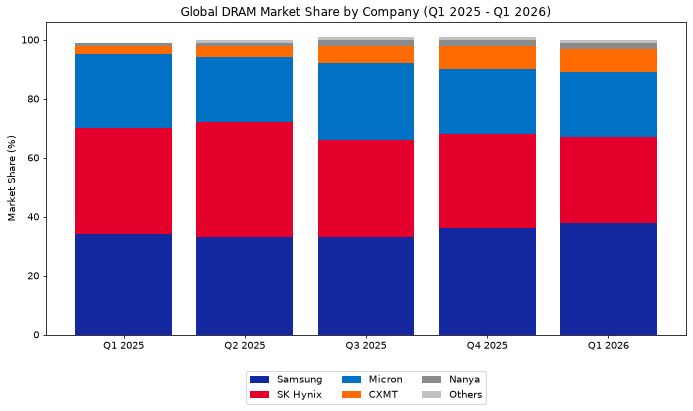

In [10]:
plt.rcParams["figure.dpi"] = 70
df = pd.read_csv("data/dram_market_share_counterpoint.csv")

# Strip % signs and convert to numeric
quarters = df.columns[1:]
for q in quarters:
    df[q] = df[q].str.rstrip("%").astype(float)

companies = df["Market Share"].tolist()
colors = {
    "Samsung": "#1428A0",
    "SK Hynix": "#E4002B",
    "Micron": "#0071C5",
    "CXMT": "#FF6B00",
    "Nanya": "#8B8B8B",
    "Others": "#C0C0C0"
}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = [0] * len(quarters)
for i, company in enumerate(companies):
    values = df.iloc[i][quarters].tolist()
    ax.bar(quarters, values, bottom=bottom, label=company, color=colors.get(company, "gray"))
    bottom = [b + v for b, v in zip(bottom, values)]
ax.set_ylabel("Market Share (%)")
ax.set_title("Global DRAM Market Share by Company (Q1 2025 - Q1 2026)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

print(df)
plt.tight_layout()
plt.show()

#### 7. Micron Financials: From Boom-Bust Commodity to Pricing Power

To understand why Micron's recent numbers are so remarkable, it helps to understand the memory
industry's history. DRAM has traditionally been one of the most notoriously cyclical, low-margin
segments in all of semiconductors, often described as a commodity business. Because DRAM chips
from different manufacturers are largely interchangeable, the industry has historically been
prone to brutal price wars when supply outpaces demand, prices collapse and margins compress toward zero or below. 
Memory suppliers, including Micron, have gone through repeated multi-year stretches of
weak profitability or outright losses during past industry downturns, a pattern well known enough
that it has its own informal name in the industry. The "memory winter." Consolidation over the
past two decades (several major suppliers went bankrupt or were acquired) has left the market
concentrated among the few large players seen in Section 6.

Micron's data in this project shows a change in dynamic. Rather than the flat-to-thin
margins typical of a commodity cycle, Micron's DRAM business shows both **exponential revenue
growth and simultaneously expanding margins**. A combination that doesn't happen in a normal
commodity market, where rising volume usually pressures prices downward, not up.

- **DRAM revenue grew from 6.12B (Q1 2025) to 31.33B (Q2 2026)**. Roughly a 5.1x increase in
  just six quarters, reflected in a 269.1% annualized CAGR.

- **Gross margin exploded to the upside, from 37.0% to 85.0%**. An **extraordinary**
  figure for a business that has historically struggled to sustain margins much above the 30-40%
  range even in good years. But is now experience gross margins in the mid 80's which is completely unheard off even in past memory boom periods. **To put into perspective how remarkable 85% gross margins are, imagine selling item X for 100, but it only costed you 15 to make.**
  
- Critically, **margin expanded fastest in the same quarters where revenue grew fastest**
  (Q4 2025 -> Q1 2026 -> Q2 2026), rather than the two metrics moving in opposite directions as a
  simple supply-and-demand commodity model would typically predict. This is strong evidence of
  genuine **pricing power** whereby Micron isn't just selling more chips, it's able to charge
  meaningfully more for them, likely because AI-driven HBM demand has outpaced the industry's
  ability to add supply (consistent with the market concentration and slow-to-build fab capacity
  discussed in Section 6).

- **NAND revenue grew alongside DRAM but at a slower pace**. 1.86B to 9.94B, roughly 5.3x (similar
  multiple to DRAM revenue), but off a smaller base and without the same margin story attached, since NAND is not
  the primary beneficiary of AI/HBM-specific demand. This divergence supports the idea that the
  current boom is specifically an HBM/DRAM phenomenon as it is a vital component to make the latest generation AI accelerator chips.

However, whether this level of margin holds is an open question that many analyst still are vary of since the memory industry's history suggests that periods of extreme pricing power have historically been followed, eventually, by renewed
oversupply once suppliers respond by expanding capacity. Micron itself has been investing heavily
in new fab capacity (see Scope Note context and Sections 2-4 on capex), which is a natural
long run response to today's high margins and the same dynamic that has ended previous memory
upcycles. This project does not attempt to forecast when or whether that will happen, but it's an
important piece of context for interpreting today's numbers. That this may be a temporary supercycle
rather than a permanent structural shift in the industry's economics.


   quarter  dram_revenue_bn  nand_revenue_bn  gross_margin quarter_dt
0  Q1 2025            6.123            1.855          37.0     2025Q1
1  Q2 2025            7.071            2.155          38.0     2025Q2
2  Q3 2025            8.984            2.252          45.7     2025Q3
3  Q4 2025           10.812            2.743          56.0     2025Q4
4  Q1 2026           18.768            4.997          74.0     2026Q1
5  Q2 2026           31.328            9.943          85.0     2026Q2


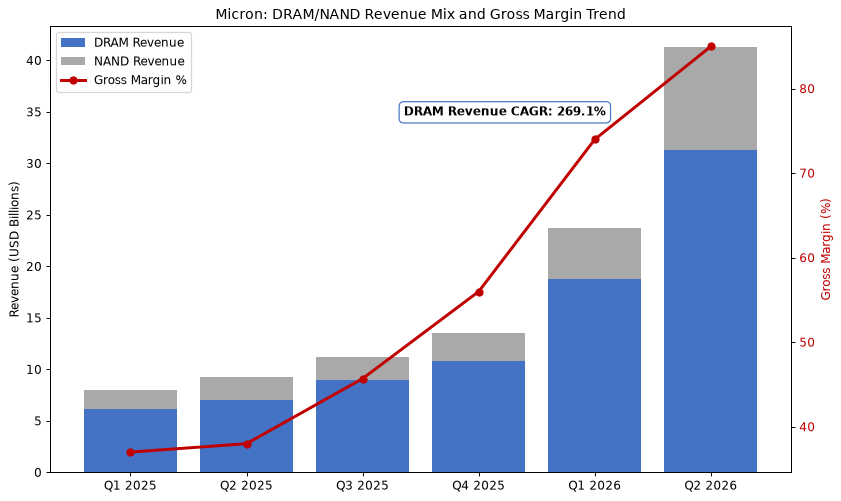

In [18]:
micron = pd.read_csv("data/micron_financials_cleaned.csv")
micron["gross_margin"] = micron["gross_margin"].str.rstrip("%").astype(float)
micron["quarter_dt"] = pd.PeriodIndex(
    micron["quarter"].str.replace(r"Q(\d) (\d+)", r"\2-Q\1", regex=True),
    freq="Q"
)
micron = micron.sort_values("quarter_dt")
print(micron)

fig, ax1 = plt.subplots(figsize=(10, 6))

#stacked bar chart for DRAM and NAND revenue
ax1.bar(micron["quarter"], micron["dram_revenue_bn"], label="DRAM Revenue", color="#4472C4")
ax1.bar(micron["quarter"], micron["nand_revenue_bn"], bottom=micron["dram_revenue_bn"],
         label="NAND Revenue", color="#A9A9A9")
ax1.set_ylabel("Revenue (USD Billions)")
ax1.set_title("Micron: DRAM/NAND Revenue Mix and Gross Margin Trend")

#line chart for gross margin on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(micron["quarter"], micron["gross_margin"], color="#C00000",
         marker="o", linewidth=2.5, label="Gross Margin %")
ax2.set_ylabel("Gross Margin (%)", color="#C00000")
ax2.tick_params(axis="y", labelcolor="#C00000")

#combine both legends into one box
bars, bar_labels = ax1.get_legend_handles_labels()
lines, line_labels = ax2.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + line_labels, loc="upper left")

#DRAM revenue CAGR annotation
dram_start = micron["dram_revenue_bn"].iloc[0]
dram_end = micron["dram_revenue_bn"].iloc[-1]
num_quarters = len(micron) - 1
dram_cagr = (dram_end / dram_start) ** (4 / num_quarters) - 1
ax1.text(0.75, 0.82, f"DRAM Revenue CAGR: {dram_cagr:.1%}",
          transform=ax1.transAxes, ha="right", va="top",
          fontsize=10, fontweight="bold",
          bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#4472C4"))

plt.tight_layout()
plt.show()

#### 8. Lag Correlation: Does Hyperscaler Capex Lead Micron's DRAM Revenue?

Testing whether capex today correlates more strongly with DRAM revenue in the same quarter, or
with a delay, across the 5 overlapping quarters (Q1 2025-Q1 2026) between the hyperscaler capex
and Micron datasets shows the strongest, most statistically significant relationship at a
1-quarter lag (r = 0.979, p = 0.021), compared to a weaker same-quarter correlation (r = 0.879,
p = 0.049) and a 2-quarter lag that loses significance entirely (r = 0.916, p = 0.263). This
suggests capex may translate into DRAM revenue with roughly one quarter of delay. In
simpler terms, when hyperscalers announce and spend on AI infrastructure, that money doesn't
show up as memory demand right away, it takes about three months to work through the supply
chain (ordering, manufacturing, shipping) before it shows up in Micron's DRAM revenue. 

However, with only 4-5 data points, this should be read as an exploratory signal rather than an
actual finding as there are too few observations to draw confident conclusions from and
correlation here doesn't establish causation, since both metrics could simply be driven by the
same underlying AI demand growth rather than one causing the other.

In [19]:
#%pip install pandas matplotlib seaborn scipy
from scipy.stats import pearsonr

#aggregate hyperscaler capex to a single total per quarter
capex_total = hyperscaler_raw.groupby(["quarter", "quarter_dt"])["capex_bn"].sum().reset_index()

#merge with Micron DRAM revenue on quarter
merged = capex_total.merge(micron[["quarter", "quarter_dt", "dram_revenue_bn"]], 
                             on=["quarter", "quarter_dt"], how="inner")
merged = merged.sort_values("quarter_dt").reset_index(drop=True)
print(merged)
print()  # blank line for output spacing

#conduct lag analysis to see if hyperscaler capex is correlated with Micron DRAM revenue with a lag of 0, 1, or 2 quarters
for lag in [0, 1, 2]:
    #shift DRAM revenue backward by `lag` quarters, so capex[t] lines up with dram_revenue[t+lag]
    shifted_dram = merged["dram_revenue_bn"].shift(-lag)
    
    valid = merged["capex_bn"].notna() & shifted_dram.notna()
    
    if valid.sum() >= 3:  #need at least 3 points for a meaningful correlation
        r, p = pearsonr(merged.loc[valid, "capex_bn"], shifted_dram[valid])
        print(f"Lag {lag} quarter(s): r = {r:.3f}, p = {p:.3f}, n = {valid.sum()}")
    else:
        print(f"Lag {lag} quarter(s): not enough overlapping data points")

   quarter quarter_dt  capex_bn  dram_revenue_bn
0  Q1 2025     2025Q1     80.99            6.123
1  Q2 2025     2025Q2     96.75            7.071
2  Q3 2025     2025Q3    109.30            8.984
3  Q4 2025     2025Q4    137.27           10.812
4  Q1 2026     2026Q1    146.24           18.768

Lag 0 quarter(s): r = 0.879, p = 0.049, n = 5
Lag 1 quarter(s): r = 0.979, p = 0.021, n = 4
Lag 2 quarter(s): r = 0.916, p = 0.263, n = 3


#### 9. DRAM Revenue vs. Gross Margin: Confirming the Pricing Power Story

Section 7 showed DRAM revenue and gross margin rising together. Testing this directly gives a strong and significant correlation (r = 0.955, p = 0.003, n = 6), confirming what the chart already suggested whereby revenue and margin are moving up together and not diverging like a typical commodity market where selling more usually pushes prices down and further suggest that memory companies have real pricing power. In other words, Micron's revenue growth has been driven substantially by pricing power rather than the volume of DRAM memory being sold alone due to a supply constrained and high demand market environment.

That said, this correlation is somewhat expected as both numbers come from the same company over the same short growth window, so they're not fully independent. This result mainly confirms and quantifies what Section 7 already showed, rather than being a new finding on its own.

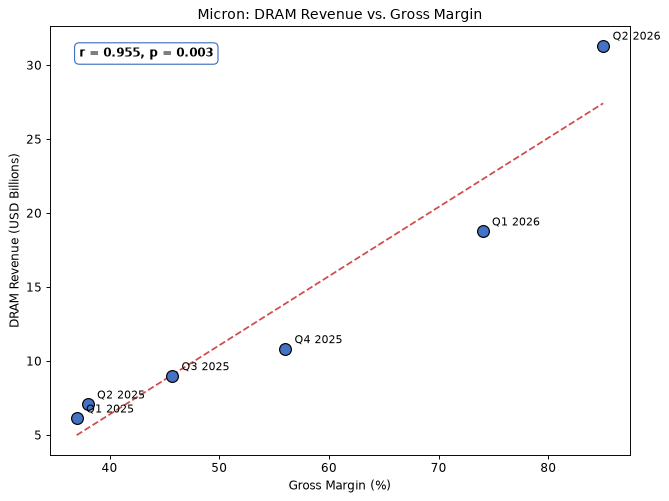

DRAM Revenue vs Gross Margin: r = 0.955, p = 0.003, n = 6


In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(micron["gross_margin"], micron["dram_revenue_bn"], 
           s=100, color="#4472C4", edgecolor="black", zorder=3)

# Label each point with its quarter
for i, row in micron.iterrows():
    ax.annotate(row["quarter"], 
                (row["gross_margin"], row["dram_revenue_bn"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# Add trendline
import numpy as np
z = np.polyfit(micron["gross_margin"], micron["dram_revenue_bn"], 1)
trendline = np.poly1d(z)
x_range = np.linspace(micron["gross_margin"].min(), micron["gross_margin"].max(), 100)
ax.plot(x_range, trendline(x_range), color="#C00000", linestyle="--", alpha=0.7, zorder=2)

ax.set_xlabel("Gross Margin (%)")
ax.set_ylabel("DRAM Revenue (USD Billions)")
ax.set_title("Micron: DRAM Revenue vs. Gross Margin")

# Annotate correlation
r, p = pearsonr(micron["dram_revenue_bn"], micron["gross_margin"])
ax.text(0.05, 0.95, f"r = {r:.3f}, p = {p:.3f}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#4472C4"))

plt.tight_layout()
plt.show()
r, p = pearsonr(micron["dram_revenue_bn"], micron["gross_margin"])
print(f"DRAM Revenue vs Gross Margin: r = {r:.3f}, p = {p:.3f}, n = {len(micron)}")

#### 10. The Full Chain: Capex -> Nvidia -> DRAM Revenue

Bringing all three datasets together on the same 5 overlapping quarters (Q1 2025-Q1 2026) shows the demand signal moving through the supply chain where hyperscaler capex climbs from 80.99B to 146.24B, Nvidia's Data Center revenue climbs from 39.11B to 75.25B, and Micron's DRAM revenue climbs from 6.12B to 18.77B. All three rising together over the same window.

The clearest feature is DRAM revenue's acceleration from Q4 2025 onward, visibly steeper than the steadier climbs in capex and Nvidia revenue above it. This lines up with the lag correlation in Section 8 whereby capex from a quarter earlier showing up as DRAM revenue now and is consistent with a market where supply couldn't keep pace with demand, pushing both revenue and pricing power higher at the same time.

   quarter quarter_dt  capex_bn  NVIDIA's quarterly revenue (billion)  \
0  Q1 2025     2025Q1     80.99                                39.112   
1  Q2 2025     2025Q2     96.75                                41.096   
2  Q3 2025     2025Q3    109.30                                51.215   
3  Q4 2025     2025Q4    137.27                                62.314   
4  Q1 2026     2026Q1    146.24                                75.246   

   dram_revenue_bn  
0            6.123  
1            7.071  
2            8.984  
3           10.812  
4           18.768  


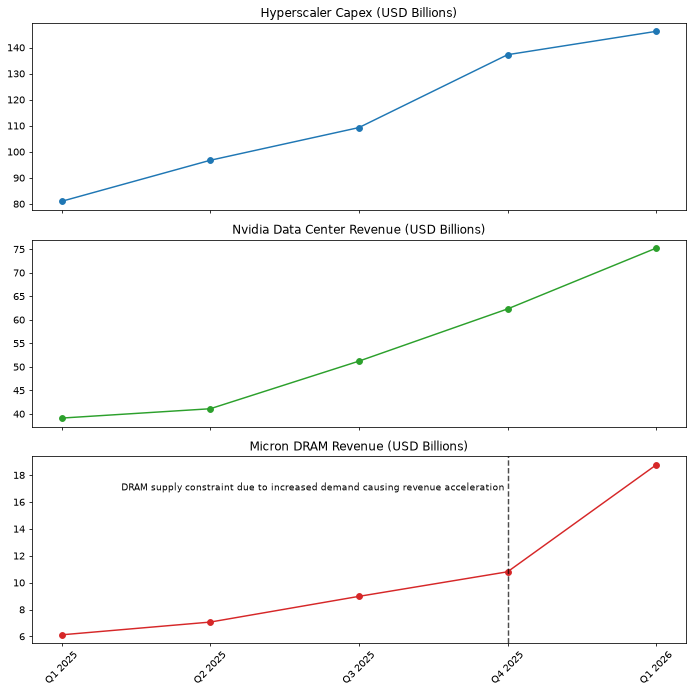

In [21]:
plt.rcParams["figure.dpi"] = 70
#merge all three datasets on quarter, keeping only quarters present in all three
combined = capex_total.merge(
    data_center[["Quarter", "NVIDIA's quarterly revenue (billion)"]].rename(columns={"Quarter": "quarter"}),
    on="quarter", how="inner"
).merge(
    micron[["quarter", "dram_revenue_bn"]],
    on="quarter", how="inner"
)

#numeric conversion for NVIDIA's quarterly revenue
combined["NVIDIA's quarterly revenue (billion)"] = pd.to_numeric(combined["NVIDIA's quarterly revenue (billion)"])
combined = combined.sort_values("quarter_dt").reset_index(drop=True)
print(combined)

#plotting the three time series in a single figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 10))

#hyperscaler capex
axes[0].plot(combined["quarter"], combined["capex_bn"], marker="o", color="tab:blue")
axes[0].set_title("Hyperscaler Capex (USD Billions)")

#Nvidia Data Center Revenue
axes[1].plot(combined["quarter"], combined["NVIDIA's quarterly revenue (billion)"], marker="o", color="tab:green")
axes[1].set_title("Nvidia Data Center Revenue (USD Billions)")

#Micron DRAM Revenue
axes[2].plot(combined["quarter"], combined["dram_revenue_bn"], marker="o", color="tab:red")
axes[2].set_title("Micron DRAM Revenue (USD Billions)")

#DRAM demand acceleration due to AI boom
quarters_list = combined["quarter"].tolist()
split_index = quarters_list.index("Q4 2025")
axes[2].axvline(x=split_index, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
axes[2].text(split_index - 0.02, axes[2].get_ylim()[1] * 0.9, "DRAM supply constraint due to increased demand causing revenue acceleration",
             rotation=0, color="black", fontsize=9, ha="right", va="top")

plt.xticks(rotation=45)
fig.tight_layout()
plt.show()